In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib as mpl

from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib,scipy,seaborn"))

Last updated: 2025-06-16T16:19:57.906461-07:00

Python implementation: CPython
Python version       : 3.13.3
IPython version      : 9.3.0

Compiler    : MSC v.1943 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 63 Stepping 2, GenuineIntel
CPU cores   : 72
Architecture: 64bit

pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.3
scipy     : 1.14.1
seaborn   : 0.13.2



Panel A NIH3T3 Sensitivity FDR trade off plot

In [2]:
smFISH_results = pd.read_csv("data/smFISH_results.csv")

In [3]:
ncells_smFISH = len(smFISH_results)
smFISH_ave_counts = np.sum(smFISH_results, axis=0)/ncells_smFISH
ncells_smFISH

288

In [4]:
cell_by_gene_mat =  pd.read_csv("data/NIH3T3/cbcsm/cell_x_barcode_mat_lf4.5_wf1.0_sf0.0_dr0.csv")
ncells_seqFISH = len(cell_by_gene_mat)
ncells_seqFISH

225

In [5]:
results = cell_by_gene_mat.set_index(["rep", "pos","cellid"]).sum()

In [6]:
results = pd.DataFrame({"seqFISH": cell_by_gene_mat.set_index(["rep", "pos","cellid"]).sum()})

In [7]:
results

,seqFISH
1700001l05rik,206
1700022a21rik,201
1700025g04rik,893
1700042g15rik,82
1700073e17rik,857
...,...
Zyg11a,112
Zyg11b,812
Zyx,17197
Zzef1,1326


In [8]:
summary_file = "data/NIH3T3/decode_summary_stats_unfiltered.csv"

nih3t3_sum_stats = pd.read_csv(summary_file)
nih3t3_sum_stats = nih3t3_sum_stats.loc[nih3t3_sum_stats.lwvf != 0]


sensitivites = []
intercepts = []
for row_num, sr in nih3t3_sum_stats.iterrows():
    cell_by_gene_mat =  pd.read_csv("data/NIH3T3/cbcsm/cell_x_barcode_mat_lf"+str(sr.lvf)+"_wf"+str(sr.lwvf)+"_sf0.0_dr0.csv")


    results = pd.DataFrame({"seqFISH_ave_counts": cell_by_gene_mat.set_index(["rep", "pos","cellid"]).sum()})/ncells_seqFISH
    
    results["smFISH_ave_counts"] = smFISH_ave_counts 
    
    results.dropna(inplace=True)
    
    lm_synd_pub = stats.linregress(results['smFISH_ave_counts'], results['seqFISH_ave_counts'])
    
    sensitivites.append(lm_synd_pub.slope)
    intercepts.append(lm_synd_pub.intercept)
    
nih3t3_sum_stats["Sensitivity"] = sensitivites
nih3t3_sum_stats["Estimated FDR"] = nih3t3_sum_stats.est_FDR
nih3t3_sum_stats["Estimated PPV"] = 1 - nih3t3_sum_stats.est_FDR
nih3t3_sum_stats["Position var penalty"] = np.int64(nih3t3_sum_stats.lvf)
nih3t3_sum_stats["Log weight var penalty"] = nih3t3_sum_stats.lwvf

In [9]:
nih3t3_sum_stats

,lvf,lwvf,svf,dr,negative_control_barcodes,gene_encoding_barcodes,est_FDR,Sensitivity,Estimated FDR,Estimated PPV,Position var penalty,Log weight var penalty
0,4.5,1.0,0,0,2076578,11538950,0.128545,0.830116,0.128545,0.871455,4,1.0
1,4.5,1.5,0,0,1899336,11209620,0.121027,0.819430,0.121027,0.878973,4,1.5
2,4.5,2.0,0,0,1764973,10880702,0.115865,0.802972,0.115865,0.884135,4,2.0
3,4.5,2.5,0,0,1658874,10553817,0.112273,0.783876,0.112273,0.887727,4,2.5
4,4.5,3.0,0,0,1572233,10230399,0.109773,0.763461,0.109773,0.890227,4,3.0
5,4.5,3.5,0,0,1498954,9916059,0.107974,0.742510,0.107974,0.892026,4,3.5
6,4.5,4.0,0,0,1435469,9611888,0.106674,0.720429,0.106674,0.893326,4,4.0
7,6.0,1.0,0,0,1568746,10332825,0.108444,0.753438,0.108444,0.891556,6,1.0
8,6.0,1.5,0,0,1414398,10005445,0.100973,0.738864,0.100973,0.899027,6,1.5
9,6.0,2.0,0,0,1296026,9680361,0.095630,0.720911,0.095630,0.904370,6,2.0


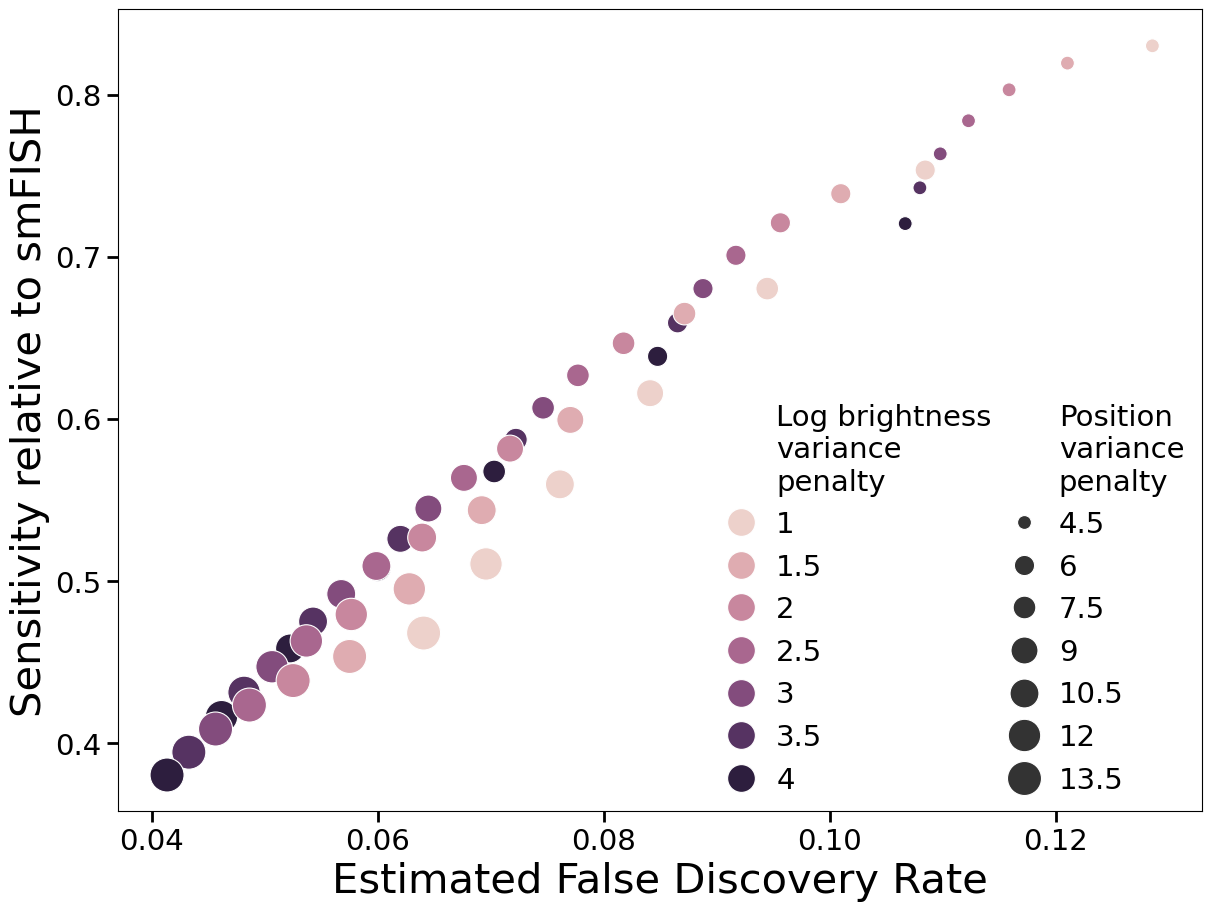

In [10]:
fig, axes = plt.subplots(1,1, figsize=(12,9), layout="constrained")

nih3t3_sum_stats

tick_width = 2
tick_length = 8
title_size=50
axis_label_size = 30
tick_label_size = 21
Panel_letter_size = 60
legend_font_size=21
marker_size_min = 100
marker_size_max = 600

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.rcParams['svg.fonttype'] = 'none'

nih3t3_sum_stats.loc[:, "Position\nvariance\npenalty"] = np.int64(nih3t3_sum_stats["lvf"])
nih3t3_sum_stats.loc[:, "Log brightness\nvariance\npenalty"] = nih3t3_sum_stats["lwvf"]

nih3t3_sen_fdr = sns.scatterplot(data=nih3t3_sum_stats, 
                                 x="Estimated FDR", 
                                 y = "Sensitivity", 
                                 size = "Position\nvariance\npenalty",
                                 hue="Log brightness\nvariance\npenalty", 
                                 ax=axes, 
                                 sizes=(marker_size_min, marker_size_max)
                                )

handles0, labels = axes.get_legend_handles_labels()
for i in range(1,8):
    handles0[i].set_markersize(20)

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.rcParams['svg.fonttype'] = 'none'

labels[1] = '1'
labels[3] = '2'
labels[5] = '3'
labels[7] = '4'
labels[9] = '4.5'
labels[11] = '7.5'
labels[13] = '10.5'
labels[15] = '13.5'

axes.legend(handles0,
           labels,
           fontsize=legend_font_size,
           ncol=2,
           columnspacing=0.1,
           loc = 'lower right',
           handletextpad= 0.2,
           borderpad=0.1,
           frameon=False,
          )

axes.set_xlabel("Estimated False Discovery Rate",fontsize=axis_label_size)
axes.tick_params(axis="both",labelsize=tick_label_size, width=tick_width, length=tick_length)

axes.set_ylabel("Sensitivity relative to smFISH",fontsize=axis_label_size)

plt.savefig('fig2A.pdf')